# General

In [1]:
import h5py
import numpy as np
from h5py import Reference
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

class Struct:
    def __init__(self, fields):
        for k, v in fields.items():
            setattr(self, k, v)

    def __repr__(self):
        keys = ", ".join(sorted(self.__dict__.keys()))
        return f"Struct({keys})"


def _from_compound(f, rec):
    """
    Convert a numpy.void (compound record) into a Struct,
    recursively converting nested compounds and references.
    """
    out = {}
    for name in rec.dtype.names:
        field = rec[name]

        # Follow HDF5 references
        if isinstance(field, Reference):
            target = f[field]
            out[name] = _load_node(f, target)

        # Nested compound
        elif isinstance(field, np.void) and field.dtype.names is not None:
            out[name] = _from_compound(f, field)

        # Scalar array -> scalar
        elif isinstance(field, np.ndarray) and field.shape == ():
            out[name] = field.item()

        else:
            out[name] = field

    return Struct(out)


def _load_node(f, node):
    """
    Recursively load any HDF5 node (group or dataset) into Python objects.
    Groups / compound datasets become Structs.
    """
    # Group: recurse on children
    if isinstance(node, h5py.Group):
        fields = {name: _load_node(f, node[name]) for name in node.keys()}
        return Struct(fields)

    # Dataset
    if isinstance(node, h5py.Dataset):
        data = node[()]

        # Scalar compound record
        if isinstance(data, np.void) and data.dtype.names is not None:
            return _from_compound(f, data)

        # 1D array of length 1 containing a compound record
        if (isinstance(data, np.ndarray) and data.dtype.names is not None
                and data.shape == (1,)):
            return _from_compound(f, data[0])

        # Scalar numeric
        if isinstance(data, np.ndarray) and data.shape == ():
            return data.item()

        # Regular array
        return data

    # Fallback
    return node


def load_res(path):

    with h5py.File(path, "r") as f:
        # Try common root names
        if "res_x" in f:
            root = f["res_x"]
        elif "res" in f:
            root = f["res"]
        else:
            # fall back to first key
            root = f[list(f.keys())[0]]

        return _load_node(f, root)

# Data

In [3]:
L_list = [8,10,12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42,44,46,48,52] 

for L in L_list:
    fname = f"Data/2d-L{L}-x.jld2"
    res = load_res(fname)

    # ======================================================
    # 1) SAMPLE-CONNECTED 
    # ======================================================
    sc_root = res.sample_connected
    sc = sc_root.product if hasattr(sc_root, "product") else sc_root


    globals()[f"C_SC_osc_stag_{L}"]      = sc.osc.stag.mean
    globals()[f"C_SC_osc_stag_err_{L}"]  = sc.osc.stag.err
    globals()[f"C_SC_osc_stag_std_{L}"]  = sc.osc.stag.std
    globals()[f"C_SC_osc_stag_var_{L}"]  = sc.osc.stag.var

    # ======================================================
    # 2) FIRST-MOMENT
    # ======================================================
    dc_root = res.disorder_connected
    dc_prod = dc_root.product if hasattr(dc_root, "product") else dc_root
    dc_fix  = dc_root.fix    if hasattr(dc_root, "fix")    else None

    globals()[f"C_DC_prod_osc_stag_{L}"]      = dc_prod.osc.stag.mean
    globals()[f"C_DC_prod_osc_stag_err_{L}"]  = dc_prod.osc.stag.err
    globals()[f"C_DC_prod_osc_stag_std_{L}"]  = dc_prod.osc.stag.std
    globals()[f"C_DC_prod_osc_stag_var_{L}"]  = dc_prod.osc.stag.var

    # ======================================================
    # GAMMA–GAMMA TWO-POINT CORRELATORS
    # ======================================================
    gg = res.gamma2pt
    ns = 200 * L
    nsqrt = np.sqrt(ns)

    # ---- Cx ----
    globals()[f"G2_Cx_{L}"]      = gg.Cx.mean
    globals()[f"G2_Cx_std_{L}"]  = gg.Cx.std
    globals()[f"G2_Cx_var_{L}"]  = gg.Cx.var
    globals()[f"G2_Cx_err_{L}"]  = gg.Cx.std / nsqrt

    # ---- Cx_abs ----
    globals()[f"G2_Cx_abs_{L}"]      = gg.Cx_abs.mean
    globals()[f"G2_Cx_abs_std_{L}"]  = gg.Cx_abs.std
    globals()[f"G2_Cx_abs_var_{L}"]  = gg.Cx_abs.var
    globals()[f"G2_Cx_abs_err_{L}"]  = gg.Cx_abs.std / nsqrt

# Fig.7

## Fig.7(a)


==== ABS-window fit with finite-size correction exp(alpha r/L) ====
Window: 12 <= L <= 52, 4 <= r <= 24, SNR_MIN=3.0, odd_only=True
Used points: 179
c0    = +4.456778 ± 0.046000   (C=exp(c0)=86.2093)
a     = +1.132787 ± 0.018303
b     = +0.392686 ± 0.016109   (b=-coef(log r))
alpha = -1.811072 ± 0.041047
RMSE(logSNR) = 0.033069
R^2(logSNR)  = 0.998233
Saved high-quality PDF as: Figs/SNR_EA_2dMajorana_finite_size.pdf


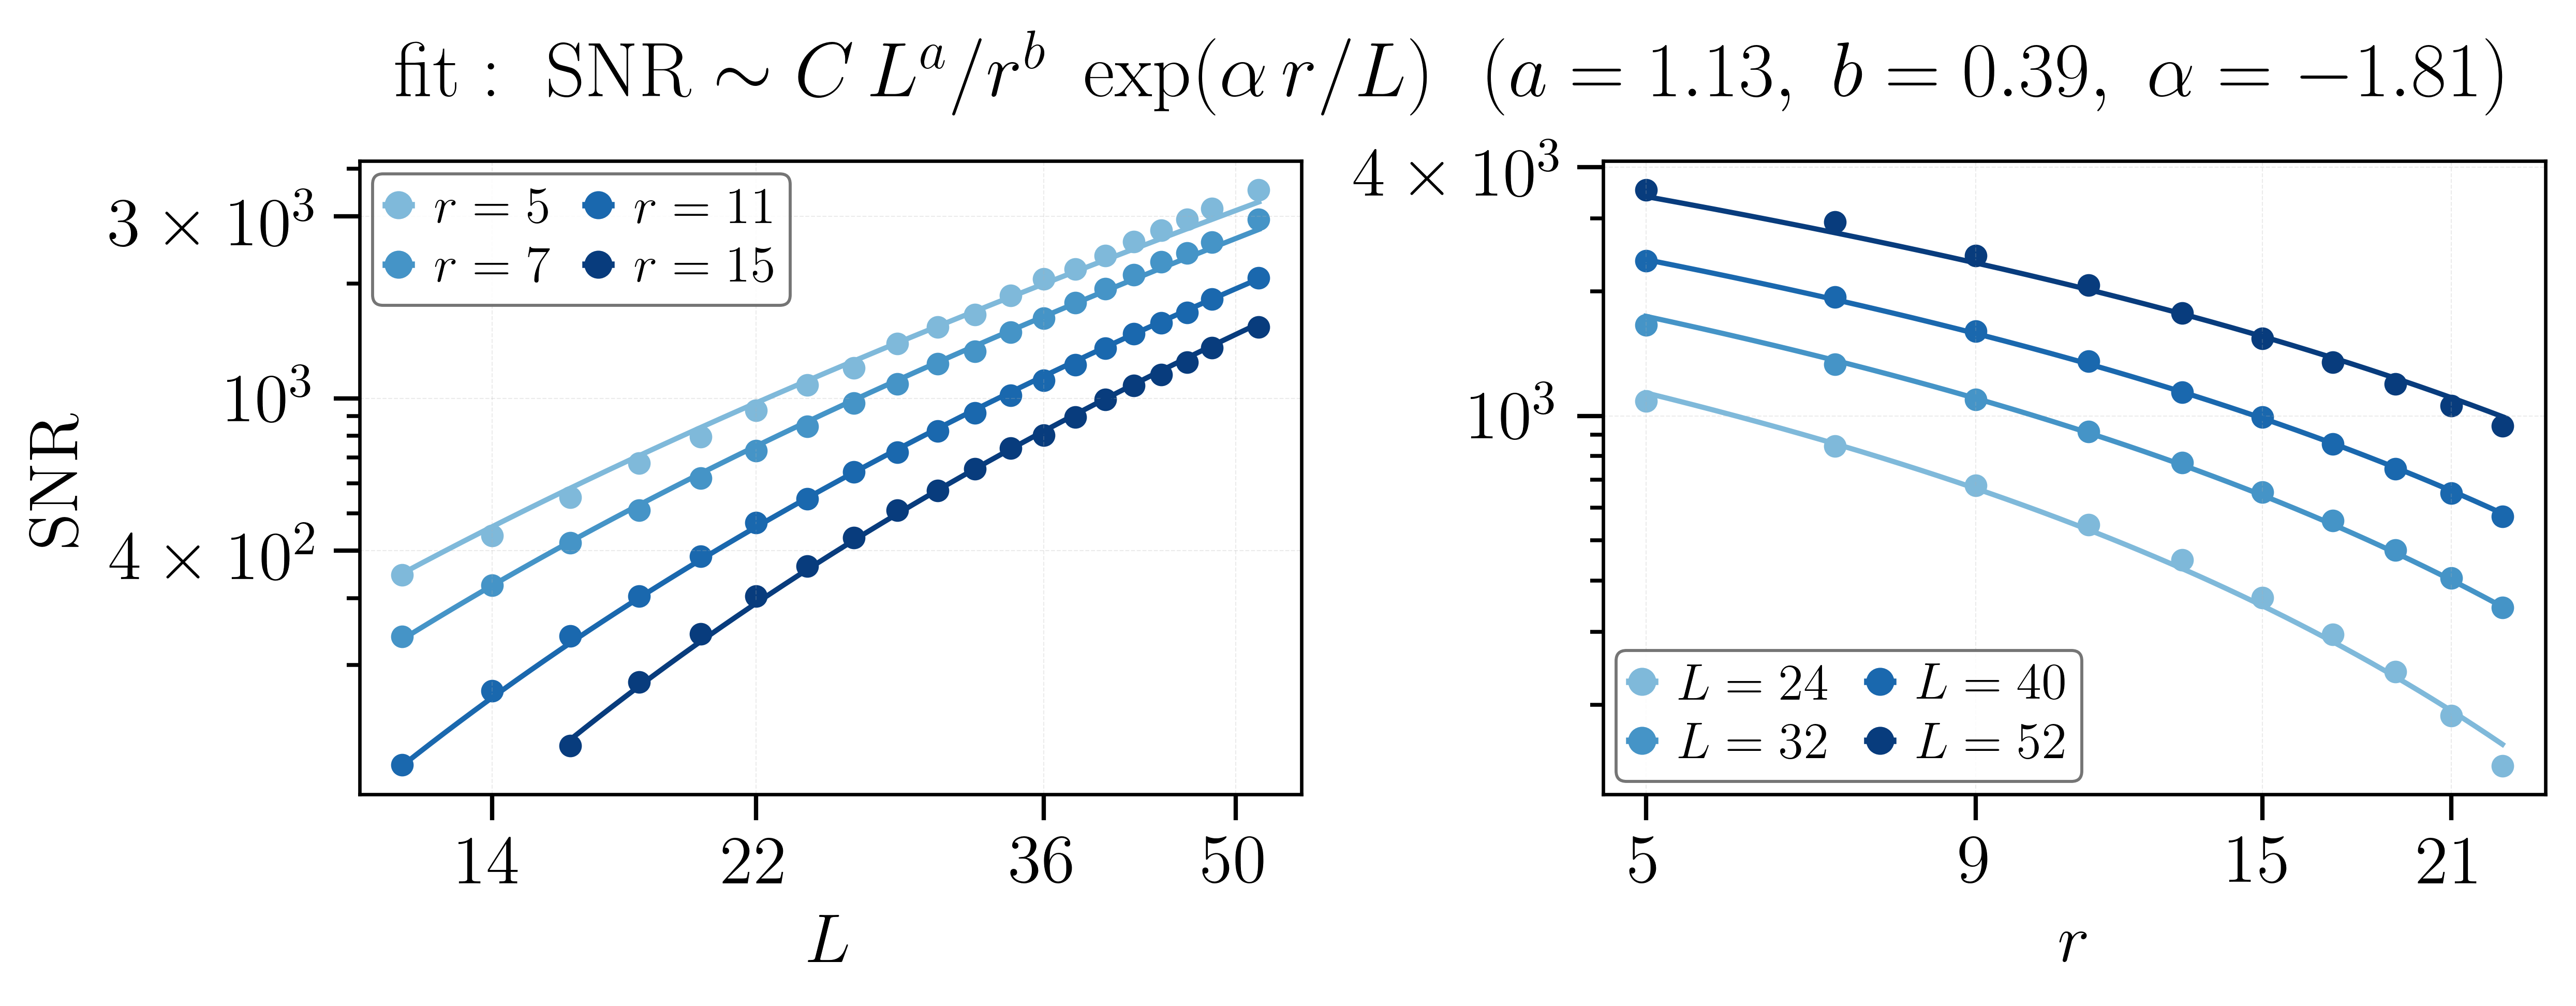

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.ticker import (
    FixedLocator, FuncFormatter, NullFormatter,
    LogLocator, NullLocator
)
from matplotlib.lines import Line2D
import matplotlib as mpl

# ---------------------------------------------------------
# Matplotlib / LaTeX settings
# ---------------------------------------------------------
mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["text.latex.preamble"] = r"""
\usepackage{amsmath}
\usepackage{amssymb}
"""

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('grid', linestyle='--', alpha=0.25)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linewidth'] = 0.25

LABEL_FSIZE  = 16
TICK_FSIZE   = 16

LEGEND_VALS_FSIZE_1 = 12
LEGEND_VALS_FSIZE_2 = 12
ROUND_AB = 2

# ============================
# MANUAL TICK CONTROLS
# ============================
X_TICKS_LEFT  = [14, 22, 36, 50]   # left panel x ticks (L)
X_TICKS_RIGHT = [5, 9, 15, 21]     # right panel x ticks (r)

X_PLAIN_INTEGERS_LEFT  = True
X_PLAIN_INTEGERS_RIGHT = True

LEFT_Y_MAJOR_TICKS  = [4e2, 1e3, 3e3]   
RIGHT_Y_MAJOR_TICKS = [1e3, 4e3]       

KEEP_Y_MINOR_TICK_MARKS = True
Y_MINOR_LEN, Y_MINOR_W = 3, 0.9
Y_MAJOR_LEN, Y_MAJOR_W = 6, 1.0
AUTO_Y_LABELED_MANTISSAS = [2, 6]

L_list = [8,10,12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42,44,46,48,52]

Y_PREFIX = "G2_Cx_abs"
E_PREFIX = "G2_Cx_abs_err"

# --------
L_MIN_FIT = 12
L_MAX_FIT = 52
R_MIN_FIT = 4
R_MAX_FIT = 24

SNR_MIN   = 3.0

L_MIN_FIXED_R = 12
L_MAX_FIXED_R = 52

ODD_ONLY = True

R_PLOT = [5, 7, 11, 15]
L_PLOT = [24, 32, 40, 52]

L_SAMPLE_RULES = [(1000, 1)]
R_SAMPLE_RULES = [(10**9, 1)]

def build_L_list_piecewise(rules, Lmax=1000):
    keep = []
    L0 = 0
    for L1, step in rules:
        keep += list(range(max(step, L0 + step), min(L1, Lmax) + 1, step))
        L0 = L1
    return sorted(set(keep))

def build_r_list_piecewise(rules, rmax):
    keep = []
    r0 = 0
    for r1, step in rules:
        r1 = min(r1, rmax)
        start = max(r0 + step, step)
        keep += list(range(start, r1 + 1, step))
        r0 = r1
        if r0 >= rmax:
            break
    return sorted(set(keep))

def keep_only_odd(int_list):
    arr = np.asarray(int_list, dtype=int)
    return arr[(arr % 2) == 1].tolist()

L_list_plot_fixed_r = build_L_list_piecewise(L_SAMPLE_RULES, Lmax=max(L_list))

MARKER_S = 18
CMAP_MIN = 0.45
CMAP_MAX = 0.95
cmap = plt.cm.Blues

def fixed_contrast_color_map(values, cmap_min=CMAP_MIN, cmap_max=CMAP_MAX):
    vals = list(map(int, values))
    k = len(vals)
    ts = [0.5] if k == 1 else np.linspace(0.0, 1.0, k)
    ts = cmap_min + (cmap_max - cmap_min) * np.asarray(ts)
    return {v: cmap(float(t)) for v, t in zip(vals, ts)}

color_by_r = fixed_contrast_color_map(R_PLOT)
color_by_L = fixed_contrast_color_map(L_PLOT)

# =========================================================
# Model and fit (finite-size correction f(r/L))
#
#   SNR ~ C * L^a / r^b * exp(alpha r/L)
#   log SNR = c0 + a log L - b log r + alpha (r/L)
#
# SIGN CONVENTION (IMPORTANT):
#   We regress on +logr; then b = -coef_logr.
# =========================================================
USE_QUADRATIC = False  

def snr_model(L, r, c0, a, b, alpha, beta_q=0.0):
    x = r / L
    return np.exp(c0) * (L**a) * (r**(-b)) * np.exp(alpha*x + beta_q*(x**2))

def fit_finite_size(rows):
    L = rows[:, 0]
    r = rows[:, 1]
    snr = rows[:, 2]

    logS = np.log(snr)
    logL = np.log(L)
    logr = np.log(r)
    x = r / L

    if USE_QUADRATIC:
        X = np.column_stack([np.ones_like(logS), logL, logr, x, x**2])
        names = ["c0", "a", "logr_coef", "alpha", "beta"]
    else:
        X = np.column_stack([np.ones_like(logS), logL, logr, x])
        names = ["c0", "a", "logr_coef", "alpha"]

    coef, *_ = np.linalg.lstsq(X, logS, rcond=None)
    yhat = X @ coef
    resid = logS - yhat

    n, p = X.shape
    dof = max(n - p, 1)
    sigma2 = float(np.sum(resid**2) / dof)
    cov = sigma2 * np.linalg.inv(X.T @ X)
    se = np.sqrt(np.diag(cov))

    rmse = float(np.sqrt(np.mean(resid**2)))
    ybar = float(np.mean(logS))
    ss_res = float(np.sum((logS - yhat)**2))
    ss_tot = float(np.sum((logS - ybar)**2))
    r2 = float(1.0 - ss_res/ss_tot) if ss_tot > 0 else np.nan

    out = {names[i]: float(coef[i]) for i in range(len(names))}
    out.update({f"{names[i]}_se": float(se[i]) for i in range(len(names))})
    out["rmse"] = rmse
    out["r2"] = r2
    out["n_points"] = int(n)
    return out

def fit_c0_fixed_r(Ls, sn, r0, a, b, alpha, beta_q=0.0):
    x = float(r0) / Ls
    return float(np.mean(np.log(sn) - a*np.log(Ls) + b*np.log(float(r0)) - (alpha*x + beta_q*(x**2))))

def fit_c0_fixed_L(rs, sn, L0, a, b, alpha, beta_q=0.0):
    x = rs / float(L0)
    return float(np.mean(np.log(sn) - a*np.log(float(L0)) + b*np.log(rs) - (alpha*x + beta_q*(x**2))))

# ---------- formatters ----------
def sci_fmt(y, _):
    if y <= 0 or (not np.isfinite(y)):
        return ""
    exp = int(np.floor(np.log10(y)))
    mant = y / (10**exp)
    if exp == 0:
        return rf"${int(round(y))}$"
    if np.isclose(mant, 1.0):
        return rf"$10^{{{exp}}}$"
    if np.isclose(mant, int(round(mant))):
        mant = int(round(mant))
    return rf"${mant}\times10^{{{exp}}}$"

def plain_int_fmt(x, _):
    if x <= 0 or (not np.isfinite(x)):
        return ""
    return rf"${int(round(x))}$"

# ---------- axis styling ----------
def style_log_axes(ax, xlabel, ylabel):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(xlabel, fontsize=LABEL_FSIZE)
    ax.set_ylabel(ylabel, fontsize=LABEL_FSIZE)
    ax.tick_params(axis='both', which='major', labelsize=TICK_FSIZE, length=Y_MAJOR_LEN, width=Y_MAJOR_W)
    ax.tick_params(axis='both', which='minor', length=Y_MINOR_LEN, width=Y_MINOR_W)

def apply_x_ticks(ax, ticks, plain_integers=True):
    ax.xaxis.set_major_locator(FixedLocator([float(t) for t in ticks]))
    ax.xaxis.set_minor_locator(NullLocator())
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.xaxis.set_major_formatter(FuncFormatter(plain_int_fmt if plain_integers else sci_fmt))

def auto_major_yticks_from_mantissas(ax, mantissas):
    y0, y1 = ax.get_ylim()
    lo, hi = (min(y0, y1), max(y0, y1))
    if lo <= 0 or hi <= 0:
        return []
    e_min = int(np.floor(np.log10(lo))) - 1
    e_max = int(np.ceil(np.log10(hi))) + 1
    mant = sorted(set([1] + [int(m) for m in mantissas if 1 <= int(m) <= 9]))
    major = []
    for e in range(e_min, e_max + 1):
        base = 10.0**e
        for m in mant:
            t = m * base
            if (t >= lo) and (t <= hi):
                major.append(float(t))
    return sorted(set(major))

def apply_y_ticks(ax, major_ticks=None, auto_mantissas=None):
    if major_ticks is None:
        major_ticks = auto_major_yticks_from_mantissas(ax, auto_mantissas or [])
    major_ticks = [float(t) for t in major_ticks if np.isfinite(t) and t > 0]
    if major_ticks:
        ax.yaxis.set_major_locator(FixedLocator(sorted(set(major_ticks))))
        ax.yaxis.set_major_formatter(FuncFormatter(sci_fmt))

    if KEEP_Y_MINOR_TICK_MARKS:
        ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
        ax.yaxis.set_minor_formatter(NullFormatter())
        ax.tick_params(axis='y', which='minor', length=Y_MINOR_LEN, width=Y_MINOR_W)
    else:
        ax.yaxis.set_minor_locator(NullLocator())
        ax.yaxis.set_minor_formatter(NullFormatter())


def build_dataset_abs(L_min, L_max, r_min, r_max, snr_min):
    rows = []
    data_by_r = defaultdict(list)
    data_by_L = defaultdict(list)

    for L in L_list:
        if (L_min is not None) and (L < int(L_min)):
            continue
        if (L_max is not None) and (L > int(L_max)):
            continue

        y_name = f"{Y_PREFIX}_{L}"
        e_name = f"{E_PREFIX}_{L}"
        if (y_name not in globals()) or (e_name not in globals()):
            continue

        y = np.asarray(globals()[y_name], dtype=float).ravel()
        e = np.asarray(globals()[e_name], dtype=float).ravel()
        n_r = int(min(len(y), len(e)))
        if n_r <= 0:
            continue

        r_hi = int(min(int(r_max), n_r))
        r_lo = int(r_min)
        if r_hi < r_lo:
            continue

        if ODD_ONLY and (r_lo % 2 == 0):
            r_lo += 1
        step = 2 if ODD_ONLY else 1

        for r in range(r_lo, r_hi + 1, step):
            err = float(e[r - 1])
            if (not np.isfinite(err)) or (err <= 0):
                continue

            val = float(y[r - 1])
            snr = abs(val) / err
            if (not np.isfinite(snr)) or (snr <= 0):
                continue

            if (snr_min is not None) and (snr < float(snr_min)):
                continue

            rows.append((float(L), float(r), float(snr)))
            data_by_r[int(r)].append((float(L), float(snr)))
            data_by_L[int(L)].append((float(r), float(snr)))

    return np.asarray(rows, float), data_by_r, data_by_L

# =========================================================
# Build + fit  + plot
# =========================================================
rows, data_by_r, data_by_L = build_dataset_abs(
    L_min=L_MIN_FIT, L_max=L_MAX_FIT,
    r_min=R_MIN_FIT, r_max=R_MAX_FIT,
    snr_min=SNR_MIN
)
if rows.size == 0:
    raise RuntimeError("No data survived absolute window. Relax SNR_MIN / widen (L,r) / check globals.")

fit = fit_finite_size(rows)
c0 = fit["c0"]
a  = fit["a"]
logr_coef = fit["logr_coef"]
b  = -logr_coef                 
alpha = fit["alpha"]
beta_q = fit["beta"] if USE_QUADRATIC else 0.0

a_leg  = round(float(a), int(ROUND_AB))
b_leg  = round(float(b), int(ROUND_AB))
al_leg = round(float(alpha), int(ROUND_AB))

print("\n==== ABS-window fit with finite-size correction exp(alpha r/L) ====")
print(f"Window: {L_MIN_FIT} <= L <= {L_MAX_FIT}, {R_MIN_FIT} <= r <= {R_MAX_FIT}, SNR_MIN={SNR_MIN}, odd_only={ODD_ONLY}")
print(f"Used points: {fit['n_points']}")
print(f"c0    = {c0:+.6f} ± {fit['c0_se']:.6f}   (C=exp(c0)={np.exp(c0):.6g})")
print(f"a     = {a:+.6f} ± {fit['a_se']:.6f}")
print(f"b     = {b:+.6f} ± {fit['logr_coef_se']:.6f}   (b=-coef(log r))")
print(f"alpha = {alpha:+.6f} ± {fit['alpha_se']:.6f}")
if USE_QUADRATIC:
    print(f"beta  = {beta_q:+.6f} ± {fit['beta_se']:.6f}")
print(f"RMSE(logSNR) = {fit['rmse']:.6f}")
print(f"R^2(logSNR)  = {fit['r2']:.6f}")

# =====================
# Plot
# =====================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), dpi=600)

# ---- Left panel: fixed r, SNR vs L ----
r_use = [r for r in R_PLOT if int(r) in data_by_r]
if ODD_ONLY:
    r_use = [r for r in r_use if (int(r) % 2 == 1)]
if len(r_use) == 0:
    raise RuntimeError("None of R_PLOT exist under")

for r0 in r_use:
    pts = np.array(data_by_r[int(r0)], float)
    if pts.size == 0:
        continue
    Ls, sn = pts[:, 0], pts[:, 1]

    mask = (Ls >= float(L_MIN_FIXED_R)) & (Ls <= float(L_MAX_FIXED_R))
    Ls, sn = Ls[mask], sn[mask]
    if Ls.size == 0:
        continue

    mask = np.isin(Ls.astype(int), np.array(L_list_plot_fixed_r, int))
    Ls, sn = Ls[mask], sn[mask]
    if Ls.size == 0:
        continue

    order = np.argsort(Ls)
    Ls, sn = Ls[order], sn[order]

    col = color_by_r[int(r0)]

    c0_slice = fit_c0_fixed_r(Ls, sn, r0, a, b, alpha, beta_q=beta_q)
    L_fit = np.logspace(np.log10(Ls.min()), np.log10(Ls.max()), 300)
    sn_fit = snr_model(L_fit, float(r0), c0_slice, a, b, alpha, beta_q=beta_q)

    ax1.scatter(Ls, sn, s=MARKER_S, color=col)
    ax1.plot(L_fit, sn_fit, lw=1.2, linestyle='-', color=col)

style_log_axes(ax1, xlabel=r"$L$", ylabel=r"$\mathrm{SNR}$")
apply_x_ticks(ax1, X_TICKS_LEFT, plain_integers=X_PLAIN_INTEGERS_LEFT)
apply_y_ticks(ax1, major_ticks=LEFT_Y_MAJOR_TICKS, auto_mantissas=AUTO_Y_LABELED_MANTISSAS)

r_handles = []
for r0 in r_use[:4]:
    col = color_by_r[int(r0)]
    r_handles.append(Line2D([0],[0], color=col, marker='o', linestyle='-',
                            markersize=5.5, label=fr"$r={int(r0)}$"))
leg1 = ax1.legend(
    handles=r_handles, fontsize=LEGEND_VALS_FSIZE_1, loc='upper left',
    ncol=2, frameon=True, handlelength=0.5, handletextpad=0.45,
    columnspacing=0.65, borderpad=0.25, labelspacing=0.25, borderaxespad=0.25
)
leg1.get_frame().set_edgecolor('0.4')
leg1.get_frame().set_linewidth(0.7)
leg1.get_frame().set_facecolor('white')
leg1.get_frame().set_alpha(0.9)

# ---- Right panel: fixed L, SNR vs r ----
L_use = [L for L in L_PLOT if int(L) in data_by_L]
if len(L_use) == 0:
    raise RuntimeError("None of L_PLOT exist")

for L0 in L_use:
    pts = np.array(data_by_L[int(L0)], float)
    if pts.size == 0:
        continue
    rs = np.asarray(pts[:, 0], float)
    sn = np.asarray(pts[:, 1], float)

    if ODD_ONLY:
        odd_mask = (rs.astype(int) % 2 == 1)
        rs, sn = rs[odd_mask], sn[odd_mask]
        if rs.size == 0:
            continue

    order = np.argsort(rs)
    rs, sn = rs[order], sn[order]

    rmax = int(rs.max())
    r_keep = np.array(build_r_list_piecewise(R_SAMPLE_RULES, rmax), int)
    if ODD_ONLY:
        r_keep = np.array(keep_only_odd(r_keep), int)

    mask = np.isin(rs.astype(int), r_keep)
    rs_th, sn_th = rs[mask], sn[mask]
    if rs_th.size == 0:
        continue

    col = color_by_L[int(L0)]

    c0_slice = fit_c0_fixed_L(rs_th, sn_th, L0, a, b, alpha, beta_q=beta_q)
    r_fit = np.logspace(np.log10(rs_th.min()), np.log10(rs_th.max()), 300)
    sn_fit = snr_model(float(L0), r_fit, c0_slice, a, b, alpha, beta_q=beta_q)

    ax2.scatter(rs_th, sn_th, s=MARKER_S, color=col)
    ax2.plot(r_fit, sn_fit, lw=1.2, linestyle='-', color=col)

style_log_axes(ax2, xlabel=r"$r$", ylabel=r"")
apply_x_ticks(ax2, X_TICKS_RIGHT, plain_integers=X_PLAIN_INTEGERS_RIGHT)
apply_y_ticks(ax2, major_ticks=RIGHT_Y_MAJOR_TICKS, auto_mantissas=AUTO_Y_LABELED_MANTISSAS)

L_handles = []
for L0 in L_use[:4]:
    col = color_by_L[int(L0)]
    L_handles.append(Line2D([0],[0], color=col, marker='o', linestyle='-',
                            markersize=5.5, label=fr"$L={int(L0)}$"))
leg2 = ax2.legend(
    handles=L_handles, fontsize=LEGEND_VALS_FSIZE_2, loc='lower left',
    ncol=2, frameon=True, handlelength=0.5, handletextpad=0.45,
    columnspacing=0.70, borderpad=0.25, labelspacing=0.25, borderaxespad=0.25
)
leg2.get_frame().set_edgecolor('0.4')
leg2.get_frame().set_linewidth(0.7)
leg2.get_frame().set_facecolor('white')
leg2.get_frame().set_alpha(0.9)

fig.suptitle(
    rf"$\mathrm{{fit}}:\ \mathrm{{SNR}}\sim C\,L^{{a}}/r^{{b}}\ \exp(\alpha\,r/L)$"
    rf"\ \ ($a={a_leg},\ b={b_leg},\ \alpha={al_leg}$)",
    fontsize=18, y=1.02, x = 0.54
)

fig.subplots_adjust(left=0.10, right=0.98, bottom=0.20, top=0.88, wspace=0.32)

pdf_name = "Figs/SNR_EA_2dMajorana_finite_size.pdf"
plt.savefig(
    pdf_name,
    format="pdf",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.08,
    transparent=False
)
print(f"Saved high-quality PDF as: {pdf_name}")

plt.show()

## Fig.7(b)


==== FIT: log SNR = c0 + a log L + b log r + alpha (r/L) ====
Used points: 89   (cuts: 12 <= L <= 52, 4 <= r <= 24, SNR_MIN=3.0)
c0    =  2.417231 ± 0.443412   (C = exp(c0) = 11.2148)
a     =  1.815526 ± 0.149497
b     = -3.706936 ± 0.135299
alpha =  1.222616 ± 0.775635
RMSE(logSNR) = 0.094448
R^2(logSNR)  = 0.989210
Saved high-quality PDF as: Figs/SNR_fm_2dMajorana_finite_size.pdf


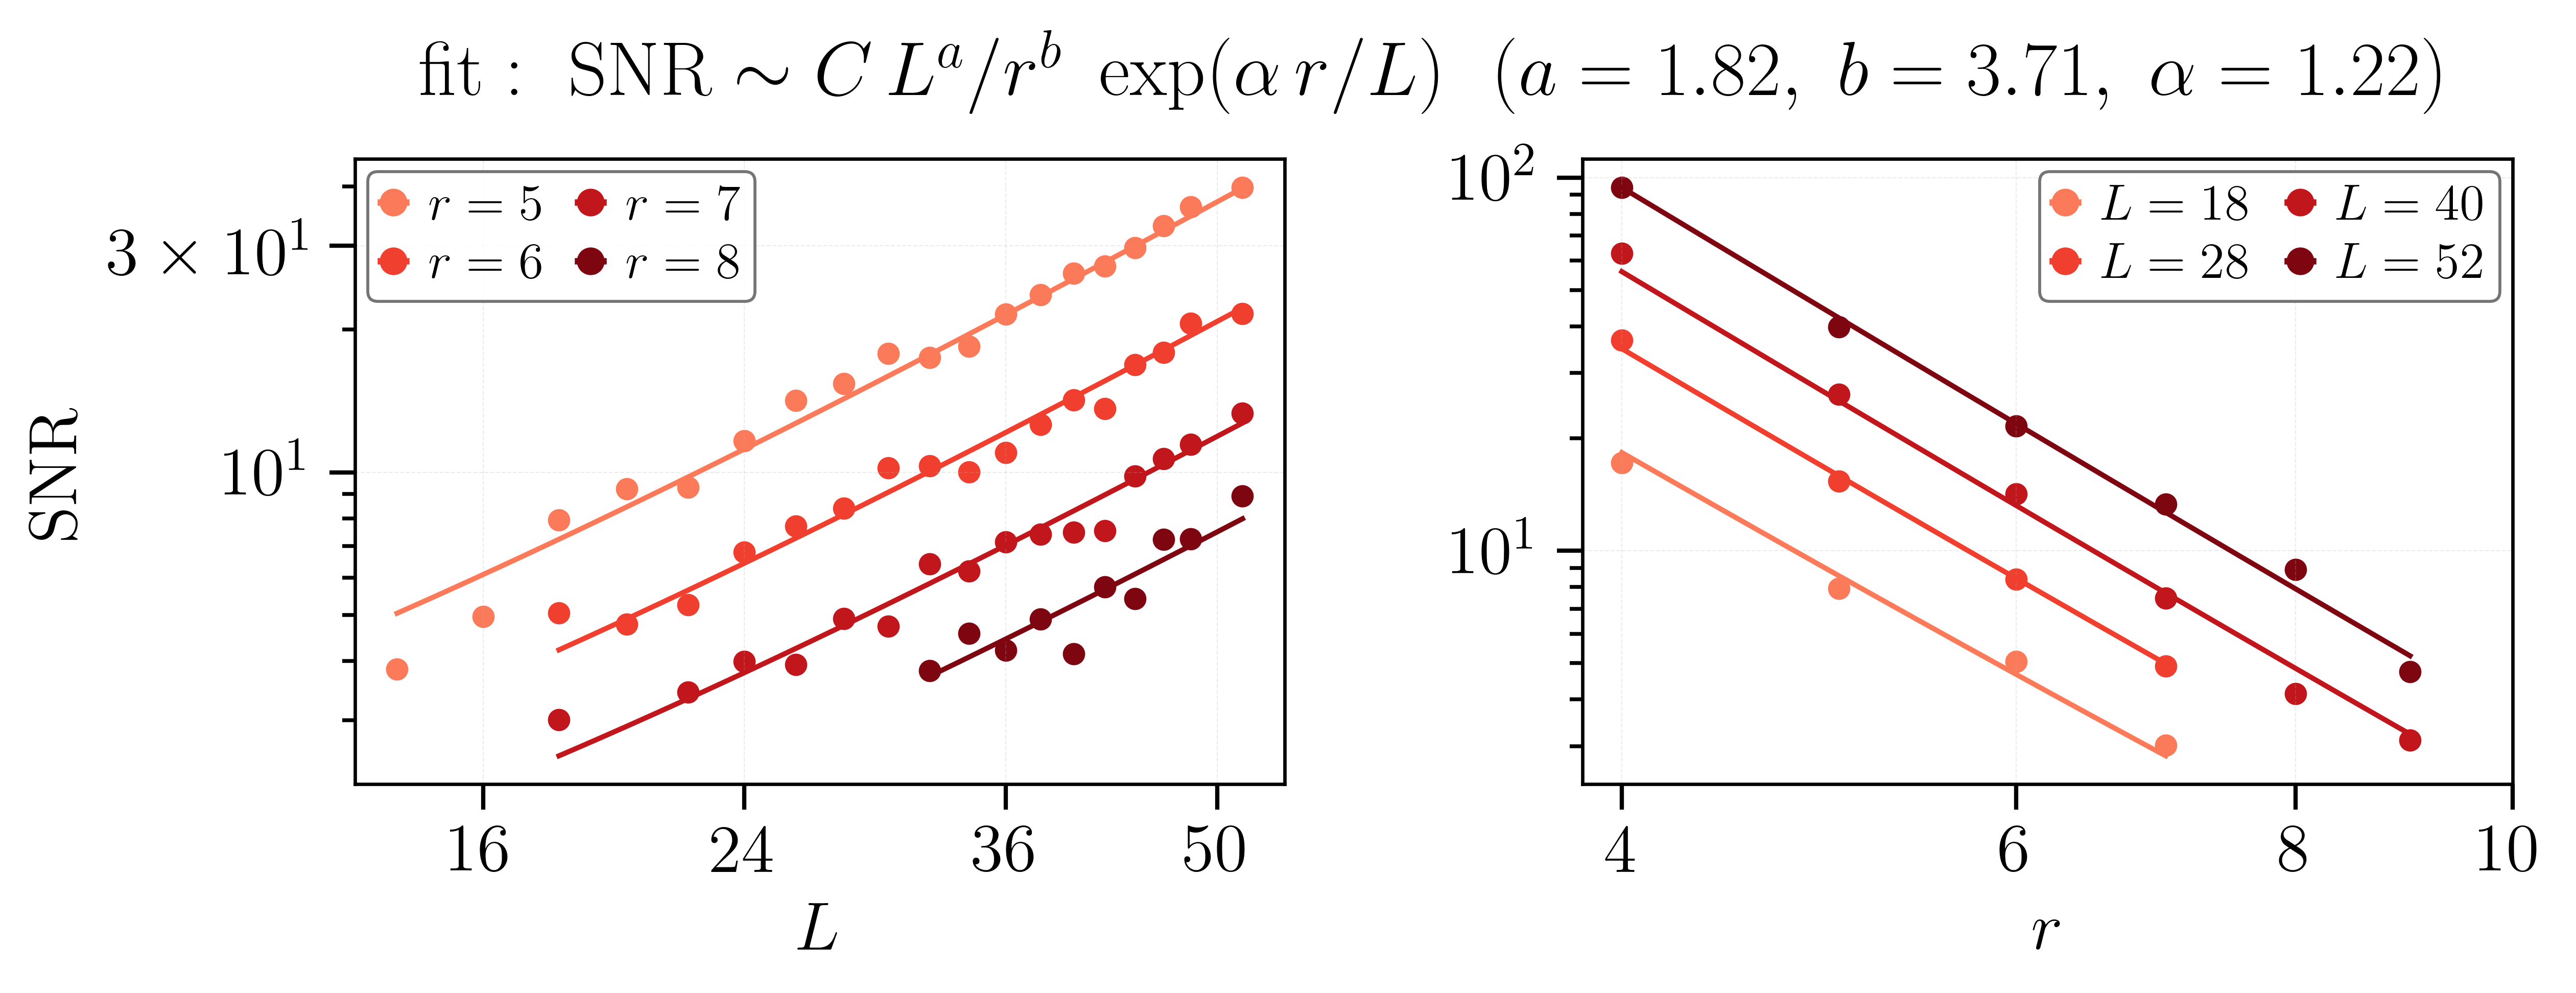

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.ticker import (
    FormatStrFormatter, NullLocator, FuncFormatter,
    FixedLocator, NullFormatter, LogLocator
)
from matplotlib.lines import Line2D
import matplotlib as mpl

# ---------------------------------------------------------
# Matplotlib / LaTeX settings
# ---------------------------------------------------------
mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["text.latex.preamble"] = r"""
\usepackage{amsmath}
\usepackage{amssymb}
"""

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('grid', linestyle='--', alpha=0.25)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linewidth'] = 0.25

LABEL_FSIZE  = 16
TICK_FSIZE   = 16

LEGEND_VALS_FSIZE_1 = 12   # left panel (r legend)
LEGEND_VALS_FSIZE_2 = 12   # right panel (L legend)


ROUND_AB = 2


LEFT_Y_MAJOR_TICKS  = [1e1, 3e1]
RIGHT_Y_MAJOR_TICKS = [1e1, 1e2]

AUTO_Y_LABELED_MANTISSAS = [2, 6]
KEEP_Y_MINOR_TICK_MARKS = True

Y_MAJOR_LEN, Y_MAJOR_W = 6, 1.0
Y_MINOR_LEN, Y_MINOR_W = 3, 0.9


L_list = [8,10,12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42,44,46,48,52]

Y_PREFIX = "C_DC_prod_osc_stag"
E_PREFIX = "C_DC_prod_osc_stag_err"

R_MIN      = 4
R_MAX_FRAC = 1        
SNR_MIN    = 3.0         

L_MIN_FIT  = 12          
L_MAX_FIT  = 52

R_MIN_FIT_ABS = R_MIN
R_MAX_FIT_ABS = 24       

L_MIN_FIXED_R = 12
L_MAX_FIXED_R = 52

ODD_ONLY = False

R_PLOT = [5, 6, 7, 8]
L_PLOT = [18, 28, 40, 52]

L_SAMPLE_RULES = [(1000, 1)]

def build_L_list_piecewise(rules, Lmax=1000):
    keep = []
    L0 = 0
    for L1, step in rules:
        keep += list(range(max(step, L0 + step), min(L1, Lmax) + 1, step))
        L0 = L1
    return sorted(set(keep))

L_list_plot_fixed_r = build_L_list_piecewise(L_SAMPLE_RULES, Lmax=max(L_list))

# ---- FIXED-L plot----
R_SAMPLE_RULES = [(10**9, 1)]

def build_r_list_piecewise(rules, rmax):
    keep = []
    r0 = 0
    for r1, step in rules:
        r1 = min(r1, rmax)
        start = max(r0 + step, step)
        keep += list(range(start, r1 + 1, step))
        r0 = r1
        if r0 >= rmax:
            break
    return sorted(set(keep))

MARKER_S = 18

# -----------------------
# Colormap control
# -----------------------
CMAP_MIN = 0.45
CMAP_MAX = 0.95
cmap = plt.cm.Reds

XTICKS_L = [16, 24, 36, 50]
XTICKS_R = [4, 6, 8, 10]


def fixed_contrast_color_map(values, cmap_min=CMAP_MIN, cmap_max=CMAP_MAX):
    vals = list(map(int, values))
    k = len(vals)
    ts = [0.5] if k == 1 else np.linspace(0.0, 1.0, k)
    ts = cmap_min + (cmap_max - cmap_min) * np.asarray(ts)
    return {v: cmap(float(t)) for v, t in zip(vals, ts)}

color_by_r = fixed_contrast_color_map(R_PLOT)
color_by_L = fixed_contrast_color_map(L_PLOT)

def sci_fmt(x, _):
    if x <= 0 or (not np.isfinite(x)):
        return ""
    exp = int(np.floor(np.log10(x)))
    mant = x / (10**exp)
    if exp == 0:
        return rf"${int(round(x))}$"
    if np.isclose(mant, 1.0):
        return rf"$10^{{{exp}}}$"
    mant_r = int(round(mant))
    if np.isclose(mant, mant_r):
        return rf"${mant_r}\times10^{{{exp}}}$"
    return rf"${mant:g}\times10^{{{exp}}}$"

def style_log_axes(ax, xlabel, ylabel, xticks=None):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(xlabel, fontsize=LABEL_FSIZE)
    ax.set_ylabel(ylabel, fontsize=LABEL_FSIZE)
    if xticks is not None:
        ax.set_xticks(xticks)
        ax.get_xaxis().set_major_formatter(FormatStrFormatter("%d"))
        ax.xaxis.set_minor_locator(NullLocator())
    ax.tick_params(axis='both', which='major', labelsize=TICK_FSIZE, length=Y_MAJOR_LEN, width=Y_MAJOR_W)
    ax.tick_params(axis='both', which='minor', length=Y_MINOR_LEN, width=Y_MINOR_W)

def auto_major_yticks_from_mantissas(ax, mantissas):
    y0, y1 = ax.get_ylim()
    lo, hi = (min(y0, y1), max(y0, y1))
    if lo <= 0 or hi <= 0:
        return []
    e_min = int(np.floor(np.log10(lo))) - 1
    e_max = int(np.ceil(np.log10(hi))) + 1
    mant = sorted(set([1] + [int(m) for m in mantissas if 1 <= int(m) <= 9]))
    major = []
    for e in range(e_min, e_max + 1):
        base = 10.0**e
        for m in mant:
            t = m * base
            if (t >= lo) and (t <= hi):
                major.append(float(t))
    return sorted(set(major))

def apply_y_ticks(ax, major_ticks=None, auto_mantissas=None):
    if major_ticks is None:
        major_ticks = auto_major_yticks_from_mantissas(ax, auto_mantissas or [])
    major_ticks = [float(t) for t in major_ticks if np.isfinite(t) and t > 0]
    if major_ticks:
        ax.yaxis.set_major_locator(FixedLocator(sorted(set(major_ticks))))
        ax.yaxis.set_major_formatter(FuncFormatter(sci_fmt))

    if KEEP_Y_MINOR_TICK_MARKS:
        ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
        ax.yaxis.set_minor_formatter(NullFormatter())
        ax.tick_params(axis='y', which='minor', length=Y_MINOR_LEN, width=Y_MINOR_W)
    else:
        ax.yaxis.set_minor_locator(NullLocator())
        ax.yaxis.set_minor_formatter(NullFormatter())

# =========================================================
# FIT MODEL: SNR ~ C * L^a * r^b * exp(alpha * r/L)
# =========================================================
USE_QUADRATIC = False 

def snr_model_corr(L, r, c0, a, b, alpha, beta_q=0.0):
    x = r / L
    return np.exp(c0) * (L**a) * (r**(b)) * np.exp(alpha*x + beta_q*(x**2))

def fit_c0_fixed_r_corr(Ls, sn, r0, a, b, alpha, beta_q=0.0):
    x = float(r0) / Ls
    # log sn = c0 + a log L + b log r0 + alpha x (+ beta x^2)
    return float(np.mean(np.log(sn) - a*np.log(Ls) - b*np.log(float(r0)) - (alpha*x + beta_q*(x**2))))

def fit_c0_fixed_L_corr(rs, sn, L0, a, b, alpha, beta_q=0.0):
    x = rs / float(L0)
    # log sn = c0 + a log L0 + b log r + alpha x (+ beta x^2)
    return float(np.mean(np.log(sn) - a*np.log(float(L0)) - b*np.log(rs) - (alpha*x + beta_q*(x**2))))

def fit_with_finite_size(rows):
    L = rows[:, 0]
    r = rows[:, 1]
    snr = rows[:, 2]

    logS = np.log(snr)
    logL = np.log(L)
    logr = np.log(r)
    x = r / L

    # logS = c0 + a logL + b logr + alpha x (+ beta x^2)
    if USE_QUADRATIC:
        X = np.column_stack([np.ones_like(logS), logL, logr, x, x**2])
        names = ["c0", "a", "b", "alpha", "beta"]
    else:
        X = np.column_stack([np.ones_like(logS), logL, logr, x])
        names = ["c0", "a", "b", "alpha"]

    beta_vec, *_ = np.linalg.lstsq(X, logS, rcond=None)
    yhat = X @ beta_vec
    resid = logS - yhat

    n, p = X.shape
    dof = max(n - p, 1)
    sigma2 = float(np.sum(resid**2) / dof)
    cov = sigma2 * np.linalg.inv(X.T @ X)
    se = np.sqrt(np.diag(cov))

    rmse = float(np.sqrt(np.mean(resid**2)))
    ybar = float(np.mean(logS))
    ss_res = float(np.sum((logS - yhat)**2))
    ss_tot = float(np.sum((logS - ybar)**2))
    r2 = float(1.0 - ss_res/ss_tot) if ss_tot > 0 else float("nan")

    out = {names[i]: float(beta_vec[i]) for i in range(len(names))}
    out.update({f"{names[i]}_se": float(se[i]) for i in range(len(names))})
    out["rmse"] = rmse
    out["r2"] = r2
    out["n_points"] = int(n)
    return out

def build_dataset(L_min_fit, L_max_fit, r_max_frac, snr_min):
    rows = []
    data_by_r = defaultdict(list)
    data_by_L = defaultdict(list)

    for L in L_list:
        if (L_min_fit is not None) and (L < int(L_min_fit)):
            continue
        if (L_max_fit is not None) and (L > int(L_max_fit)):
            continue

        y_name = f"{Y_PREFIX}_{L}"
        e_name = f"{E_PREFIX}_{L}"
        if (y_name not in globals()) or (e_name not in globals()):
            continue

        y = np.asarray(globals()[y_name], dtype=float).ravel()
        e = np.asarray(globals()[e_name], dtype=float).ravel()
        n_r = int(min(len(y), len(e)))
        if n_r <= 0:
            continue

        r_max_avail = int(min(n_r, np.floor(float(r_max_frac) * float(L))))
        if r_max_avail < int(R_MIN):
            continue

        # ---- ABSOLUTE r window for fit+plot dataset ----
        r_max = int(min(r_max_avail, int(R_MAX_FIT_ABS)))
        if r_max < int(R_MIN_FIT_ABS):
            continue

        r_start = int(R_MIN_FIT_ABS)
        if ODD_ONLY and (r_start % 2 == 0):
            r_start += 1
        step = 2 if ODD_ONLY else 1

        for r in range(r_start, r_max + 1, step):
            err = float(e[r - 1])
            if (not np.isfinite(err)) or (err <= 0):
                continue

            val = float(y[r - 1])
            snr = abs(val) / err
            if (not np.isfinite(snr)) or (snr <= 0):
                continue

            if (snr_min is not None) and (snr < float(snr_min)):
                continue

            rows.append((float(L), float(r), float(snr)))
            data_by_r[int(r)].append((float(L), float(snr)))
            data_by_L[int(L)].append((float(r), float(snr)))

    rows = np.asarray(rows, dtype=float)
    return rows, data_by_r, data_by_L

rows, data_by_r, data_by_L = build_dataset(
    L_min_fit=L_MIN_FIT,
    L_max_fit=L_MAX_FIT,
    r_max_frac=R_MAX_FRAC,
    snr_min=SNR_MIN
)

if rows.size == 0:
    raise RuntimeError("No data survived cuts. Relax SNR_MIN / increase R_MAX_FIT_ABS / check globals.")

fit = fit_with_finite_size(rows)

c0 = fit["c0"]
a  = fit["a"]
b  = fit["b"]
alpha = fit["alpha"]
beta_q = fit["beta"] if USE_QUADRATIC else 0.0

a_leg  = round(float(a), int(ROUND_AB))
b_leg  = round(float(b), int(ROUND_AB))
al_leg = round(float(alpha), int(ROUND_AB))

print("\n==== FIT: log SNR = c0 + a log L + b log r + alpha (r/L) ====")
print(
    f"Used points: {fit['n_points']}   "
    f"(cuts: {L_MIN_FIT} <= L <= {L_MAX_FIT}, {R_MIN_FIT_ABS} <= r <= {R_MAX_FIT_ABS}, "
    f"SNR_MIN={SNR_MIN})"
)
print(f"c0    = {c0: .6f} ± {fit['c0_se']:.6f}   (C = exp(c0) = {np.exp(c0):.6g})")
print(f"a     = {a: .6f} ± {fit['a_se']:.6f}")
print(f"b     = {b: .6f} ± {fit['b_se']:.6f}")
print(f"alpha = {alpha: .6f} ± {fit['alpha_se']:.6f}")
if USE_QUADRATIC:
    print(f"beta  = {beta_q: .6f} ± {fit['beta_se']:.6f}")
print(f"RMSE(logSNR) = {fit['rmse']:.6f}")
print(f"R^2(logSNR)  = {fit['r2']:.6f}")

# =============================================================
# Plot
# =============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), dpi=600)

# ---- Left panel ----
r_use = [r for r in R_PLOT if (int(r) in data_by_r)]
for r0 in r_use:
    pts = np.array(data_by_r[int(r0)], dtype=float)
    if pts.size == 0:
        continue
    Ls, sn = pts[:, 0], pts[:, 1]

    mask = (Ls >= float(L_MIN_FIXED_R)) & (Ls <= float(L_MAX_FIXED_R))
    Ls, sn = Ls[mask], sn[mask]
    if Ls.size == 0:
        continue

    mask = np.isin(Ls.astype(int), np.array(L_list_plot_fixed_r, dtype=int))
    Ls, sn = Ls[mask], sn[mask]
    if Ls.size == 0:
        continue

    order = np.argsort(Ls)
    Ls, sn = Ls[order], sn[order]

    col = color_by_r[int(r0)]
    c0_slice = fit_c0_fixed_r_corr(Ls, sn, r0, a, b, alpha, beta_q=beta_q)
    L_fit = np.logspace(np.log10(Ls.min()), np.log10(Ls.max()), 300)
    sn_fit = snr_model_corr(L_fit, float(r0), c0_slice, a, b, alpha, beta_q=beta_q)

    ax1.scatter(Ls, sn, s=MARKER_S, color=col)
    ax1.plot(L_fit, sn_fit, lw=1.2, linestyle='-', color=col)

style_log_axes(ax1, xlabel=r"$L$", ylabel=r"$\mathrm{SNR}$", xticks=XTICKS_L)
apply_y_ticks(ax1, major_ticks=LEFT_Y_MAJOR_TICKS, auto_mantissas=AUTO_Y_LABELED_MANTISSAS)

r_handles = []
for r0 in r_use[:4]:
    col = color_by_r[int(r0)]
    r_handles.append(Line2D([0],[0], color=col, marker='o', linestyle='-',
                            markersize=5.5, label=fr"$r={int(r0)}$"))
leg1 = ax1.legend(
    handles=r_handles,
    fontsize=LEGEND_VALS_FSIZE_1,
    loc='upper left',
    ncol=2,
    frameon=True,
    handlelength=0.5,
    handletextpad=0.45,
    columnspacing=0.65,
    borderpad=0.25,
    labelspacing=0.25,
    borderaxespad=0.25
)
leg1.get_frame().set_edgecolor('0.4')
leg1.get_frame().set_linewidth(0.7)
leg1.get_frame().set_facecolor('white')
leg1.get_frame().set_alpha(0.9)

# ---- Right panel ----
L_use = [L for L in L_PLOT if int(L) in data_by_L]
for L0 in L_use:
    pts = np.array(data_by_L[int(L0)], dtype=float)
    if pts.size == 0:
        continue

    rs = np.asarray(pts[:, 0], float)
    sn = np.asarray(pts[:, 1], float)

    order = np.argsort(rs)
    rs, sn = rs[order], sn[order]

    rmax = int(rs.max())
    r_keep = np.array(build_r_list_piecewise(R_SAMPLE_RULES, rmax), dtype=int)

    mask = np.isin(rs.astype(int), r_keep)
    rs_th, sn_th = rs[mask], sn[mask]
    if rs_th.size == 0:
        continue

    col = color_by_L[int(L0)]
    c0_slice = fit_c0_fixed_L_corr(rs_th, sn_th, L0, a, b, alpha, beta_q=beta_q)
    r_fit = np.logspace(np.log10(rs_th.min()), np.log10(rs_th.max()), 300)
    sn_fit = snr_model_corr(float(L0), r_fit, c0_slice, a, b, alpha, beta_q=beta_q)

    ax2.scatter(rs_th, sn_th, s=MARKER_S, color=col)
    ax2.plot(r_fit, sn_fit, lw=1.2, linestyle='-', color=col)

style_log_axes(ax2, xlabel=r"$r$", ylabel=r"", xticks=XTICKS_R)
apply_y_ticks(ax2, major_ticks=RIGHT_Y_MAJOR_TICKS, auto_mantissas=AUTO_Y_LABELED_MANTISSAS)

L_handles = []
for L0 in L_use[:4]:
    col = color_by_L[int(L0)]
    L_handles.append(Line2D([0],[0], color=col, marker='o', linestyle='-',
                            markersize=5.5, label=fr"$L={int(L0)}$"))
leg2 = ax2.legend(
    handles=L_handles,
    fontsize=LEGEND_VALS_FSIZE_2,
    loc='upper right',
    ncol=2,
    frameon=True,
    handlelength=0.5,
    handletextpad=0.45,
    columnspacing=0.70,
    borderpad=0.25,
    labelspacing=0.25,
    borderaxespad=0.25
)
leg2.get_frame().set_edgecolor('0.4')
leg2.get_frame().set_linewidth(0.7)
leg2.get_frame().set_facecolor('white')
leg2.get_frame().set_alpha(0.9)

# ---- Title ----
if USE_QUADRATIC:
    fig.suptitle(
        rf"$\mathrm{{fit}}:\ \mathrm{{SNR}}\sim C\,L^{{a}}r^{{b}}\ \exp(\alpha\,r/L+\beta(r/L)^2)$"
        rf"\ \ ($a={a_leg},\ b={b_leg},\ \alpha={al_leg}$)",
        fontsize=18, y=1.02
    )
else:
    fig.suptitle(
        rf"$\mathrm{{fit}}:\ \mathrm{{SNR}}\sim C\,L^{{a}}/r^{{b}}\ \exp(\alpha\,r/L)$"
        rf"\ \ ($a={a_leg},\ b={-b_leg},\ \alpha={al_leg}$)",
        fontsize=18, y=1.02, x=0.54
    )

fig.subplots_adjust(left=0.10, right=0.98, bottom=0.20, top=0.88, wspace=0.32)

pdf_name = "Figs/SNR_fm_2dMajorana_finite_size.pdf"
plt.savefig(
    pdf_name,
    format="pdf",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.08,
    transparent=False
)
print(f"Saved high-quality PDF as: {pdf_name}")

plt.show()

## Fig.7(c)


==== ABS-window fit with finite-size correction f(r/L) ====
Window: 12 <= L <= 52, 4 <= r <= 24, SNR_MIN=3
Used points: 359
c0    = +6.544362 ± 0.132570   (C=exp(c0)=695.313)
a     = +0.116096 ± 0.051991
b     = -0.095570 ± 0.046116
alpha = -6.353972 ± 0.128236
RMSE(logSNR) = 0.136824
R^2(logSNR)  = 0.988387
Saved: Figs/SNR_sc_2dMajorana_finite_size.pdf


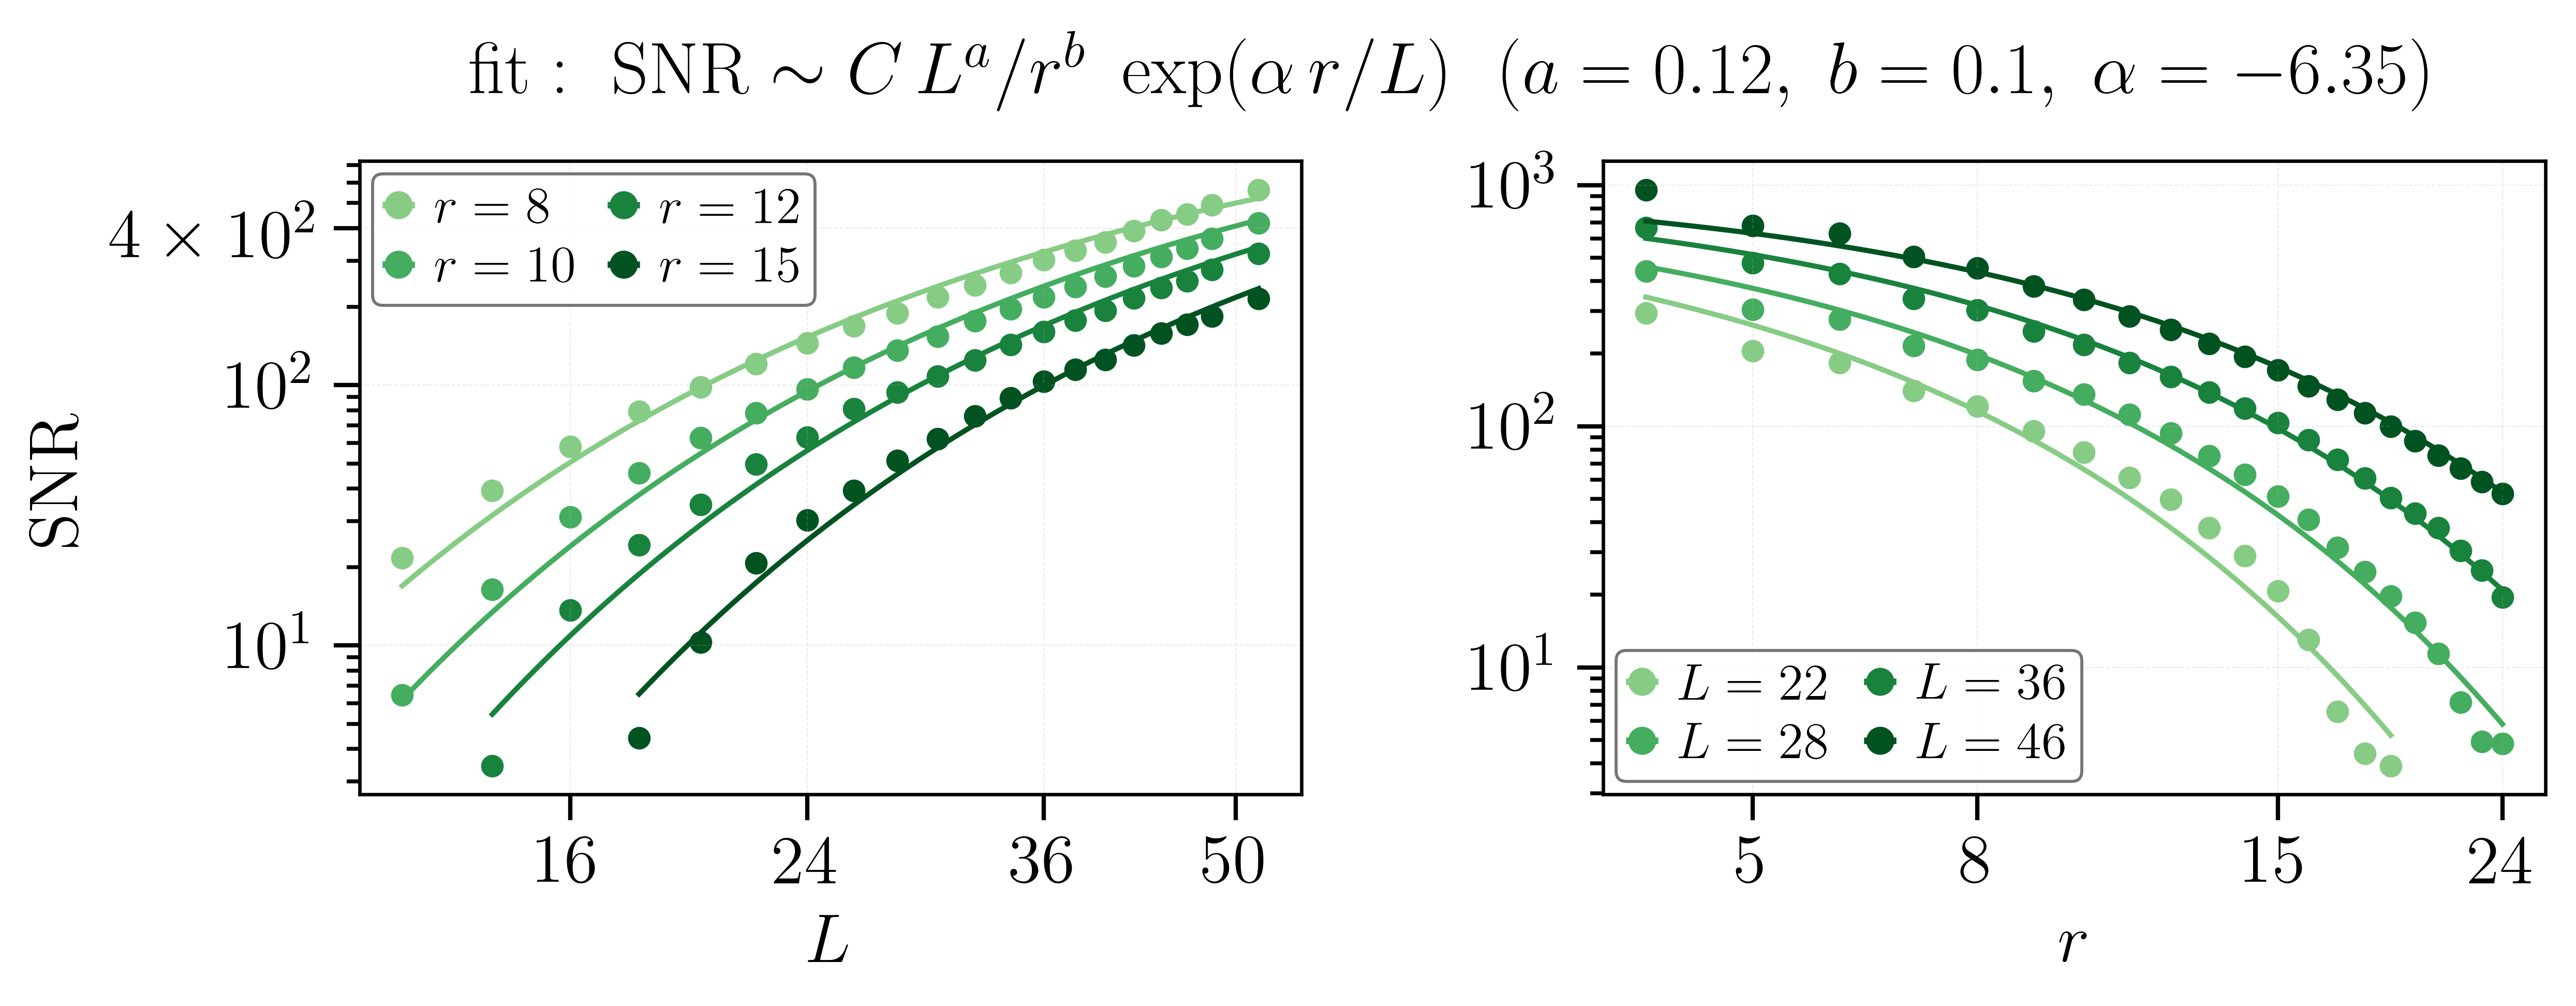

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.ticker import (
    FormatStrFormatter, NullLocator, FuncFormatter,
    FixedLocator, NullFormatter, LogLocator
)
from matplotlib.lines import Line2D
import matplotlib as mpl

# ------------------------------
# Matplotlib / LaTeX settings 
# -------------------------------
mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["text.latex.preamble"] = r"""
\usepackage{amsmath}
\usepackage{amssymb}
"""
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('grid', linestyle='--', alpha=0.25)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linewidth'] = 0.25

LEGEND_FONTSIZE = 12
LABEL_FSIZE  = 16
TICK_FSIZE   = 16
ROUND_AB     = 2
MARKER_S     = 18

# =========================================================
# DATA SETTINGS (EDIT)
# =========================================================
L_list = [8,10,12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42,44,46,48,52]

Y_PREFIX = "C_SC_osc_stag"
E_PREFIX = "C_SC_osc_stag_err"

# --- Absolute fit window (NO r/L cut) ---
L_MIN_FIT = 12
L_MAX_FIT = 52
R_MIN_FIT = 4
R_MAX_FIT = 24          # <-- absolute r_max, not fraction of L

SNR_MIN   = 3           # None disables

# slices to display
R_PLOT = [8, 10, 12, 15]
L_PLOT = [22, 28, 36, 46]

# extra left-panel L window (after dataset build)
L_MIN_FIXED_R = 12
L_MAX_FIXED_R = 52

ODD_ONLY = False

# ---------------------------------------------------------
# Sampling rules for plotting (not for fitting)
# ---------------------------------------------------------
L_SAMPLE_RULES = [(1000, 1)]
R_SAMPLE_RULES = [(50, 1)]

def build_L_list_piecewise(rules, Lmax=1000):
    keep = []
    L0 = 0
    for L1, step in rules:
        keep += list(range(max(step, L0 + step), min(L1, Lmax) + 1, step))
        L0 = L1
    return sorted(set(keep))

def build_r_list_piecewise(rules, rmax):
    keep = []
    r0 = 0
    for r1, step in rules:
        r1 = min(r1, rmax)
        start = max(r0 + step, step)
        keep += list(range(start, r1 + 1, step))
        r0 = r1
        if r0 >= rmax:
            break
    return sorted(set(keep))

L_list_plot_fixed_r = build_L_list_piecewise(L_SAMPLE_RULES, Lmax=max(L_list))

# -----------------------
# Colormap control
# ------------------------
CMAP_MIN = 0.45
CMAP_MAX = 0.95
cmap = plt.cm.Greens

XTICKS_L = [16, 24, 36, 50]
XTICKS_R = [5, 8, 15, 24]

def fixed_contrast_color_map(values, cmap_min=CMAP_MIN, cmap_max=CMAP_MAX):
    vals = list(map(int, values))
    k = len(vals)
    ts = [0.5] if k == 1 else np.linspace(0.0, 1.0, k)
    ts = cmap_min + (cmap_max - cmap_min) * np.asarray(ts)
    return {v: cmap(float(t)) for v, t in zip(vals, ts)}

color_by_r = fixed_contrast_color_map(R_PLOT)
color_by_L = fixed_contrast_color_map(L_PLOT)

# ===========================
# Formatting / axis helpers
# ===========================
def sci_fmt(x, _):
    if x <= 0 or (not np.isfinite(x)):
        return ""
    exp = int(np.floor(np.log10(x)))
    mant = x / (10**exp)
    if exp == 0:
        return rf"${int(round(x))}$"
    if np.isclose(mant, 1.0):
        return rf"$10^{{{exp}}}$"
    mant_r = int(round(mant))
    if np.isclose(mant, mant_r):
        return rf"${mant_r}\times10^{{{exp}}}$"
    return rf"${mant:g}\times10^{{{exp}}}$"

def style_log_axes(ax, xlabel, ylabel, xticks=None):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(xlabel, fontsize=LABEL_FSIZE)
    ax.set_ylabel(ylabel, fontsize=LABEL_FSIZE)
    if xticks is not None:
        ax.set_xticks(xticks)
        ax.get_xaxis().set_major_formatter(FormatStrFormatter("%d"))
        ax.xaxis.set_minor_locator(NullLocator())
    ax.tick_params(axis='both', which='major', labelsize=TICK_FSIZE, length=6, width=1.0)
    ax.tick_params(axis='both', which='minor', length=3, width=0.9)


# =========================================================
def build_dataset_abs(L_min, L_max, r_min, r_max, snr_min):
    rows = []
    data_by_r = defaultdict(list)
    data_by_L = defaultdict(list)

    for L in L_list:
        if (L_min is not None) and (L < int(L_min)): continue
        if (L_max is not None) and (L > int(L_max)): continue

        y_name = f"{Y_PREFIX}_{L}"
        e_name = f"{E_PREFIX}_{L}"
        if (y_name not in globals()) or (e_name not in globals()):
            continue

        y = np.asarray(globals()[y_name], dtype=float).ravel()
        e = np.asarray(globals()[e_name], dtype=float).ravel()
        n_r = int(min(len(y), len(e)))
        if n_r <= 0:
            continue

        r_hi = min(int(r_max), n_r)
        r_lo = int(r_min)

        # optional odd-only
        if ODD_ONLY and (r_lo % 2 == 0):
            r_lo += 1
        step = 2 if ODD_ONLY else 1

        for r in range(r_lo, r_hi + 1, step):
            err = float(e[r - 1])
            if (not np.isfinite(err)) or (err <= 0):
                continue

            val = float(y[r - 1])
            snr = abs(val) / err
            if (not np.isfinite(snr)) or (snr <= 0):
                continue

            if (snr_min is not None) and (snr < float(snr_min)):
                continue

            rows.append((float(L), float(r), float(snr)))
            data_by_r[int(r)].append((float(L), float(snr)))
            data_by_L[int(L)].append((float(r), float(snr)))

    return np.asarray(rows, dtype=float), data_by_r, data_by_L

# =========================================================
# Fit model with finite-size correction f(r/L)
#
#   log SNR = c0 + a log L - b log r + alpha (r/L)        
# =========================================================
USE_QUADRATIC = False  

def fit_finite_size(rows):
    L = rows[:, 0]
    r = rows[:, 1]
    snr = rows[:, 2]

    logS = np.log(snr)
    logL = np.log(L)
    logr = np.log(r)
    x = r / L

    if USE_QUADRATIC:
        X = np.column_stack([np.ones_like(logS), logL, -logr, x, x**2])
        names = ["c0", "a", "b", "alpha", "beta"]
    else:
        X = np.column_stack([np.ones_like(logS), logL, -logr, x])
        names = ["c0", "a", "b", "alpha"]

    beta, *_ = np.linalg.lstsq(X, logS, rcond=None)
    yhat = X @ beta
    resid = logS - yhat

    n, p = X.shape
    dof = max(n - p, 1)
    sigma2 = float(np.sum(resid**2) / dof)
    cov = sigma2 * np.linalg.inv(X.T @ X)
    se = np.sqrt(np.diag(cov))

    rmse = float(np.sqrt(np.mean(resid**2)))
    ybar = float(np.mean(logS))
    ss_res = float(np.sum((logS - yhat)**2))
    ss_tot = float(np.sum((logS - ybar)**2))
    r2 = float(1.0 - ss_res/ss_tot) if ss_tot > 0 else float("nan")

    out = {names[i]: float(beta[i]) for i in range(len(names))}
    out.update({f"{names[i]}_se": float(se[i]) for i in range(len(names))})
    out["rmse"] = rmse
    out["r2"] = r2
    out["n_points"] = int(n)
    return out

def snr_model(L, r, c0, a, b, alpha, beta_q=0.0):
    x = r / L
    return np.exp(c0) * (L**a) * (r**(-b)) * np.exp(alpha*x + beta_q*(x**2))

def fit_c0_fixed_r(Ls, sn, r0, a, b, alpha, beta_q=0.0):
    x = float(r0) / Ls
    return float(np.mean(np.log(sn) - a*np.log(Ls) + b*np.log(float(r0)) - (alpha*x + beta_q*(x**2))))

def fit_c0_fixed_L(rs, sn, L0, a, b, alpha, beta_q=0.0):
    x = rs / float(L0)
    return float(np.mean(np.log(sn) - a*np.log(float(L0)) + b*np.log(rs) - (alpha*x + beta_q*(x**2))))

# =========================================================
# Run: build (ABS window) + fit + plot
# =========================================================
rows, data_by_r, data_by_L = build_dataset_abs(
    L_min=L_MIN_FIT, L_max=L_MAX_FIT,
    r_min=R_MIN_FIT, r_max=R_MAX_FIT,
    snr_min=SNR_MIN
)

if rows.size == 0:
    raise RuntimeError("No data survived absolute cuts. Relax SNR_MIN / widen (L,r) window / check globals.")

fit = fit_finite_size(rows)

c0 = fit["c0"]
a  = fit["a"]
b  = fit["b"]
alpha = fit["alpha"]
beta_q = fit["beta"] if USE_QUADRATIC else 0.0

print("\n==== ABS-window fit with finite-size correction f(r/L) ====")
print(f"Window: {L_MIN_FIT} <= L <= {L_MAX_FIT}, {R_MIN_FIT} <= r <= {R_MAX_FIT}, SNR_MIN={SNR_MIN}")
print(f"Used points: {fit['n_points']}")
print(f"c0    = {c0:+.6f} ± {fit['c0_se']:.6f}   (C=exp(c0)={np.exp(c0):.6g})")
print(f"a     = {a:+.6f} ± {fit['a_se']:.6f}")
print(f"b     = {b:+.6f} ± {fit['b_se']:.6f}")
print(f"alpha = {alpha:+.6f} ± {fit['alpha_se']:.6f}")
if USE_QUADRATIC:
    print(f"beta  = {beta_q:+.6f} ± {fit['beta_se']:.6f}")
print(f"RMSE(logSNR) = {fit['rmse']:.6f}")
print(f"R^2(logSNR)  = {fit['r2']:.6f}")

a_leg  = round(float(a), int(ROUND_AB))
b_leg  = round(float(b), int(ROUND_AB))
al_leg = round(float(alpha), int(ROUND_AB))

# =========================================================
# =========================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), dpi=600)

# ---- Left panel: fixed r (SNR vs L) ----
r_use = [r for r in R_PLOT if int(r) in data_by_r]
if len(r_use) == 0:
    raise RuntimeError("None of R_PLOT exist")

for r0 in r_use:
    pts = np.array(data_by_r[int(r0)], dtype=float)
    if pts.size == 0:
        continue
    Ls, sn = pts[:, 0], pts[:, 1]

    # extra L window for left panel
    mask = (Ls >= float(L_MIN_FIXED_R)) & (Ls <= float(L_MAX_FIXED_R))
    Ls, sn = Ls[mask], sn[mask]
    if Ls.size == 0:
        continue

    # plotting subsampling (optional)
    mask = np.isin(Ls.astype(int), np.array(L_list_plot_fixed_r, dtype=int))
    Ls, sn = Ls[mask], sn[mask]
    if Ls.size == 0:
        continue

    order = np.argsort(Ls)
    Ls, sn = Ls[order], sn[order]

    col = color_by_r[int(r0)]

    # slice intercept for amplitude 
    c0_slice = fit_c0_fixed_r(Ls, sn, r0, a, b, alpha, beta_q=beta_q)

    L_fit = np.logspace(np.log10(Ls.min()), np.log10(Ls.max()), 300)
    sn_fit = snr_model(L_fit, float(r0), c0_slice, a, b, alpha, beta_q=beta_q)

    ax1.scatter(Ls, sn, s=MARKER_S, color=col)
    ax1.plot(L_fit, sn_fit, lw=1.2, linestyle='-', color=col)

style_log_axes(ax1, xlabel=r"$L$", ylabel=r"$\mathrm{SNR}$", xticks=XTICKS_L)
# ---- Left panel y ticks: add 2*10^2 as a major tick (keep minor ticks) ----
ax1.yaxis.set_major_locator(FixedLocator([1e1, 1e2, 4e2]))  # add 2×10^2
ax1.yaxis.set_major_formatter(FuncFormatter(sci_fmt))
ax1.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1))
ax1.yaxis.set_minor_formatter(NullFormatter())

r_handles = []
for r0 in r_use[:4]:
    col = color_by_r[int(r0)]
    r_handles.append(Line2D([0],[0], color=col, marker='o', linestyle='-',
                            markersize=5.5, label=fr"$r={int(r0)}$"))
leg1 = ax1.legend(
    handles=r_handles,
    fontsize=LEGEND_FONTSIZE,
    loc='upper left',
    ncol=2,
    frameon=True,
    handlelength=0.5,
    handletextpad=0.45,
    columnspacing=0.65,
    borderpad=0.25,
    labelspacing=0.25,
    borderaxespad=0.25
)
leg1.get_frame().set_edgecolor('0.4')
leg1.get_frame().set_linewidth(0.7)
leg1.get_frame().set_facecolor('white')
leg1.get_frame().set_alpha(0.9)

# ---- Right panel: fixed L (SNR vs r) ----
L_use = [L for L in L_PLOT if int(L) in data_by_L]
if len(L_use) == 0:
    raise RuntimeError("None of L_PLOT exist under")

for L0 in L_use:
    pts = np.array(data_by_L[int(L0)], dtype=float)
    if pts.size == 0:
        continue

    rs = np.asarray(pts[:, 0], float)
    sn = np.asarray(pts[:, 1], float)

    order = np.argsort(rs)
    rs, sn = rs[order], sn[order]

    # plotting subsampling in r
    rmax = int(rs.max())
    r_keep = np.array(build_r_list_piecewise(R_SAMPLE_RULES, rmax), dtype=int)
    if ODD_ONLY:
        r_keep = r_keep[(r_keep % 2) == 1]

    mask = np.isin(rs.astype(int), r_keep)
    rs_th, sn_th = rs[mask], sn[mask]
    if rs_th.size == 0:
        continue

    col = color_by_L[int(L0)]

    # slice intercept
    c0_slice = fit_c0_fixed_L(rs_th, sn_th, L0, a, b, alpha, beta_q=beta_q)

    r_fit = np.logspace(np.log10(rs_th.min()), np.log10(rs_th.max()), 300)
    sn_fit = snr_model(float(L0), r_fit, c0_slice, a, b, alpha, beta_q=beta_q)

    ax2.scatter(rs_th, sn_th, s=MARKER_S, color=col)
    ax2.plot(r_fit, sn_fit, lw=1.2, linestyle='-', color=col)

style_log_axes(ax2, xlabel=r"$r$", ylabel=r"", xticks=XTICKS_R)
ax2.yaxis.set_major_formatter(FuncFormatter(sci_fmt))
ax2.yaxis.set_minor_formatter(NullFormatter())

L_handles = []
for L0 in L_use[:4]:
    col = color_by_L[int(L0)]
    L_handles.append(Line2D([0],[0], color=col, marker='o', linestyle='-',
                            markersize=5.5, label=fr"$L={int(L0)}$"))
leg2 = ax2.legend(
    handles=L_handles,
    fontsize=LEGEND_FONTSIZE,
    loc='lower left',
    ncol=2,
    frameon=True,
    handlelength=0.5,
    handletextpad=0.45,
    columnspacing=0.70,
    borderpad=0.25,
    labelspacing=0.25,
    borderaxespad=0.25
)
leg2.get_frame().set_edgecolor('0.4')
leg2.get_frame().set_linewidth(0.7)
leg2.get_frame().set_facecolor('white')
leg2.get_frame().set_alpha(0.9)

# ---- Title ----
if USE_QUADRATIC:
    fig.suptitle(
        rf"$\mathrm{{fit}}:\ \mathrm{{SNR}}\sim C\,L^{{a}}/r^{{b}}\ \exp(\alpha\,r/L+\beta(r/L)^2)$"
        rf"\ \ ($a={a_leg},\ b={b_leg},\ \alpha={al_leg}$)",
        fontsize=17, y=1.02
    )
else:
    fig.suptitle(
        rf"$\mathrm{{fit}}:\ \mathrm{{SNR}}\sim C\,L^{{a}}/r^{{b}}\ \exp(\alpha\,r/L)$"
        rf"\ \ ($a={a_leg},\ b={-b_leg},\ \alpha={al_leg}$)",
        fontsize=17, y=1.02, x=0.54
    )

fig.subplots_adjust(left=0.10, right=0.98, bottom=0.20, top=0.88, wspace=0.32)

pdf_name = "Figs/SNR_sc_2dMajorana_finite_size.pdf"
plt.savefig(pdf_name, format="pdf", dpi=600, bbox_inches="tight", pad_inches=0.08, transparent=False)
print(f"Saved: {pdf_name}")

plt.show()